## Plotting and checks

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import sys
import numpy as np
import glob

# Import utils
sys.path.append('/home/565/dh4185/mn51-dh4185/repos_collab/nesp_bff/')
# from utils import locations
import utils

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xclim/sdba.py:12: UserWarning: The `xclim.sdba` module has been split into its own package `xsdba`. Users are encouraged to use `xsdba` directly. For the time being, `xclim.sdba` will import `xsdba` to allow for API compatibility. This behaviour may change in the future. For more information, see: https://xsdba.readthedocs.io/en/stable/xclim_migration_guide.html
  warnings.warn(


In [2]:
# locations = {'Darwin':{'Lat':-12.42,'Lon':130.89,'Elev':30}, # BOM station: 014015
#              'Cairns':{'Lat':-16.87,'Lon':145.75,'Elev':2}, # BOM station: 031011
#              'Brisbane':{'Lat':-27.48,'Lon':153.04,'Elev':8}, # BOM station: 040913
#              'Longreach':{'Lat':-23.44,'Lon':144.28,'Elev':192}, # BOM station: 036031
#              'Mildura':{'Lat':-34.23,'Lon':142.09,'Elev':50}, # BOM station: 076031
#              'Adelaide':{'Lat':-34.95,'Lon':138.51,'Elev':2}, # BOM station: 023034
#              'Perth':{'Lat':-31.92,'Lon':115.87,'Elev':25}, # BOM station: 009225
#              'Sydney':{'Lat':-33.95,'Lon':151.17,'Elev':39}, # BOM stations: 066062/066214
#              'Melbourne':{'Lat':-37.67,'Lon':144.83,'Elev':31}, # BOM stations: 086071/086338
#              'Canberra':{'Lat':-35.31,'Lon':149.19,'Elev':577}, # BOM station: 070351
#              'Hobart':{'Lat':-42.89,'Lon':147.33,'Elev':51}, # BOM station: 094029
#              'Thredbo':{'Lat':-36.50,'Lon':148.29,'Elev':1380}} # BOM station: 071041

locations = utils.locations
locations

{'Melbourne': {'Lat': -37.666, 'Lon': 144.832, 'Elev': 118.8},
 'Canberra': {'Lat': -35.305, 'Lon': 149.201, 'Elev': 580.0},
 'Darwin': {'Lat': -12.424, 'Lon': 130.893, 'Elev': 35.0},
 'Cairns': {'Lat': -16.874, 'Lon': 145.746, 'Elev': 8.3},
 'Brisbane': {'Lat': -27.392, 'Lon': 153.129, 'Elev': 9.5},
 'Longreach': {'Lat': -23.437, 'Lon': 144.277, 'Elev': 192.5},
 'Mildura': {'Lat': -34.236, 'Lon': 142.087, 'Elev': 51.1},
 'Adelaide': {'Lat': -34.921, 'Lon': 138.622, 'Elev': 51.0},
 'Perth': {'Lat': -31.927, 'Lon': 115.976, 'Elev': 20.0},
 'Sydney': {'Lat': -33.941, 'Lon': 151.173, 'Elev': 5.0},
 'Hobart': {'Lat': -42.89, 'Lon': 147.328, 'Elev': 51.4},
 'Thredbo': {'Lat': -36.49, 'Lon': 148.3, 'Elev': 1380.0}}

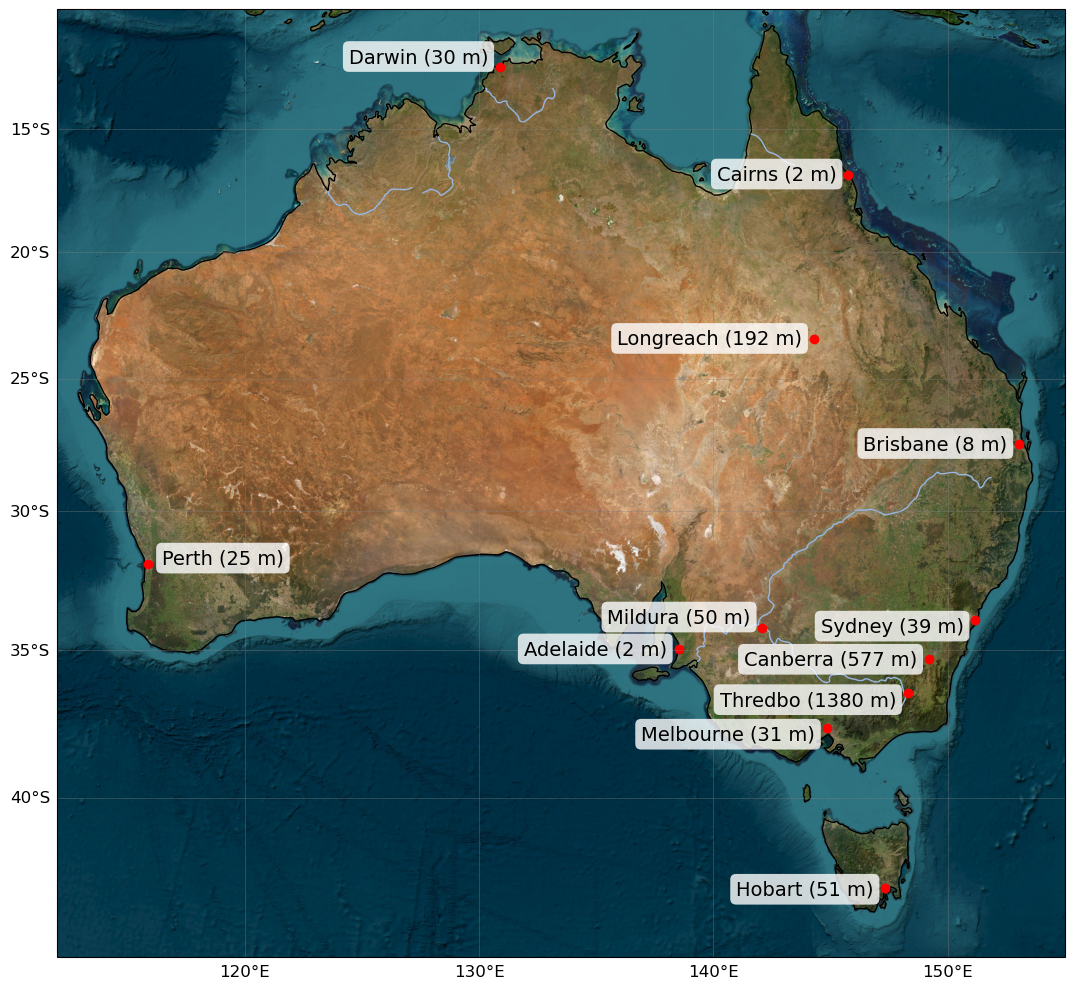

In [3]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.img_tiles import GoogleTiles
import matplotlib.ticker as mticker

# Custom ESRI imagery tile class
class EsriImagery(GoogleTiles):
    def _image_url(self, tile):
        x, y, z = tile
        return f"https://services.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"

# Load basemap
tiler = EsriImagery()
crs = tiler.crs

# Station locations
locations = {
    'Darwin': {'Lat': -12.42, 'Lon': 130.89, 'Elev': 30},
    'Cairns': {'Lat': -16.87, 'Lon': 145.75, 'Elev': 2},
    'Brisbane': {'Lat': -27.48, 'Lon': 153.04, 'Elev': 8},
    'Longreach': {'Lat': -23.44, 'Lon': 144.28, 'Elev': 192},
    'Mildura': {'Lat': -34.23, 'Lon': 142.09, 'Elev': 50},
    'Adelaide': {'Lat': -34.95, 'Lon': 138.51, 'Elev': 2},
    'Perth': {'Lat': -31.92, 'Lon': 115.87, 'Elev': 25},
    'Sydney': {'Lat': -33.95, 'Lon': 151.17, 'Elev': 39},
    'Melbourne': {'Lat': -37.67, 'Lon': 144.83, 'Elev': 31},
    'Canberra': {'Lat': -35.31, 'Lon': 149.19, 'Elev': 577},
    'Hobart': {'Lat': -42.89, 'Lon': 147.33, 'Elev': 51},
    'Thredbo': {'Lat': -36.50, 'Lon': 148.29, 'Elev': 1380}
}

# Adjust all labels to the left of their marker
offsets = {
    name: (-0.5, -0.2) for name in locations
}
# Specific tweaks for better spacing near borders or other cities
offsets.update({
    'Darwin': (-0.5, 0.2),
    'Cairns': (-0.5, -0.2),
    'Brisbane': (-0.5, -0.2),
    'Sydney': (-0.5, -0.4),
    'Canberra': (-0.5, -0.2),
    'Melbourne': (-0.5, -0.4),
    'Thredbo': (-0.5, -0.4),
    'Mildura':(-0.5, 0.2),
    'Perth':(5.8,0)
})

# Plot setup
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=crs)
ax.set_extent([112, 155, -45, -10], crs=ccrs.PlateCarree())
ax.add_image(tiler, 6)

# Features
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS)

# Plot stations
for name, info in locations.items():
    lat, lon, elev = info['Lat'], info['Lon'], info['Elev']
    offset_lon, offset_lat = offsets[name]

    ax.plot(lon, lat, 'ro', transform=ccrs.PlateCarree())
    ax.text(
        lon + offset_lon, lat + offset_lat,
        f"{name} ({elev} m)",
        fontsize=14,
        color='black',
        transform=ccrs.PlateCarree(),
        bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.3', edgecolor='none'),
        horizontalalignment='right'
    )

# Gridlines
gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(),
                  linewidth=0.5, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}
gl.xlocator = mticker.FixedLocator(range(110, 161, 10))
gl.ylocator = mticker.FixedLocator(range(-45, -9, 5))

# plt.title("12 requested locations", fontsize=14)
plt.tight_layout()
plt.savefig("/home/565/dh4185/mn51-dh4185/repos_collab/nesp_bff/locations_on_satmap.png", dpi=300, bbox_inches='tight')
plt.show()


In [26]:
# ESRI World Imagery tiles
class EsriImagery(GoogleTiles):
    def _image_url(self, tile):
        x, y, z = tile
        return (
            "https://services.arcgisonline.com/ArcGIS/rest/services/"
            f"World_Imagery/MapServer/tile/{z}/{y}/{x}"
        )

tiler = EsriImagery()
tile_crs = tiler.crs

def fmt_coord(lat, lon, elev=None):
    if elev:
        return f"{lat:.2f}°, {lon:.2f}°, {elev:.1f}m"
    else:
        return f"{lat:.2f}°, {lon:.2f}°"


In [5]:
ec_earth = xr.open_dataset("/g/data/py18/BARPA/output/CMIP6/DD/AUST-15/BOM/EC-Earth3/historical/r1i1p1f1/BARPA-R/v1-r1/fx/orog/latest/orog_AUST-15_EC-Earth3_historical_r1i1p1f1_BOM_BARPA-R_v1-r1_fx.nc").orog
access = xr.open_dataset("/g/data/py18/BARPA/output/CMIP6/DD/AUST-15/BOM/ACCESS-ESM1-5/historical/r6i1p1f1/BARPA-R/v1-r1/fx/orog/latest/orog_AUST-15_ACCESS-ESM1-5_historical_r6i1p1f1_BOM_BARPA-R_v1-r1_fx.nc").orog

In [6]:
locations["Hobart"]["Elev"]

51

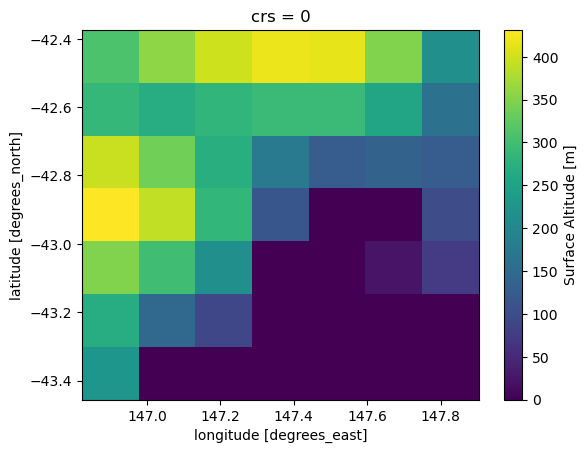

In [7]:
ec_earth.sel(lat=slice(locations["Hobart"]["Lat"]-0.5,locations["Hobart"]["Lat"]+0.5),
             lon=slice(locations["Hobart"]["Lon"]-0.5,locations["Hobart"]["Lon"]+0.5)).plot()
# (ec_earth-access).plot()

In [8]:
##### Find the closest valid grid cell for each location
barra_v = "BARPA-R" #"BARRA-R2" # BARRA-C2

### Read land fraction and orog files
if barra_v == "BARRA-R2":
    sftlf = xr.open_dataset("/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/fx/sftlf/latest/sftlf_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1.nc").sftlf
    orog = xr.open_dataset("/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/fx/orog/latest/orog_AUST-15_ACCESS-ESM1-5_historical_r6i1p1f1_BOM_BARPA-R_v1-r1_fx.nc").orog
elif barra_v == "BARRA-C2":
    sftlf = xr.open_dataset("/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/fx/sftlf/latest/sftlf_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1.nc").sftlf
    orog = xr.open_dataset("/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/fx/orog/latest/sftlf/latest/orog_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1.nc").orog
elif barra_v == "BARPA-R":
    sftlf = xr.open_dataset("/g/data/py18/BARPA/output/CMIP6/DD/AUST-15/BOM/ACCESS-ESM1-5/historical/r6i1p1f1/BARPA-R/v1-r1/fx/sftlf/latest/sftlf_AUST-15_ACCESS-ESM1-5_historical_r6i1p1f1_BOM_BARPA-R_v1-r1_fx.nc").sftlf
    orog = xr.open_dataset("/g/data/py18/BARPA/output/CMIP6/DD/AUST-15/BOM/ACCESS-ESM1-5/historical/r6i1p1f1/BARPA-R/v1-r1/fx/orog/latest/orog_AUST-15_ACCESS-ESM1-5_historical_r6i1p1f1_BOM_BARPA-R_v1-r1_fx.nc").orog


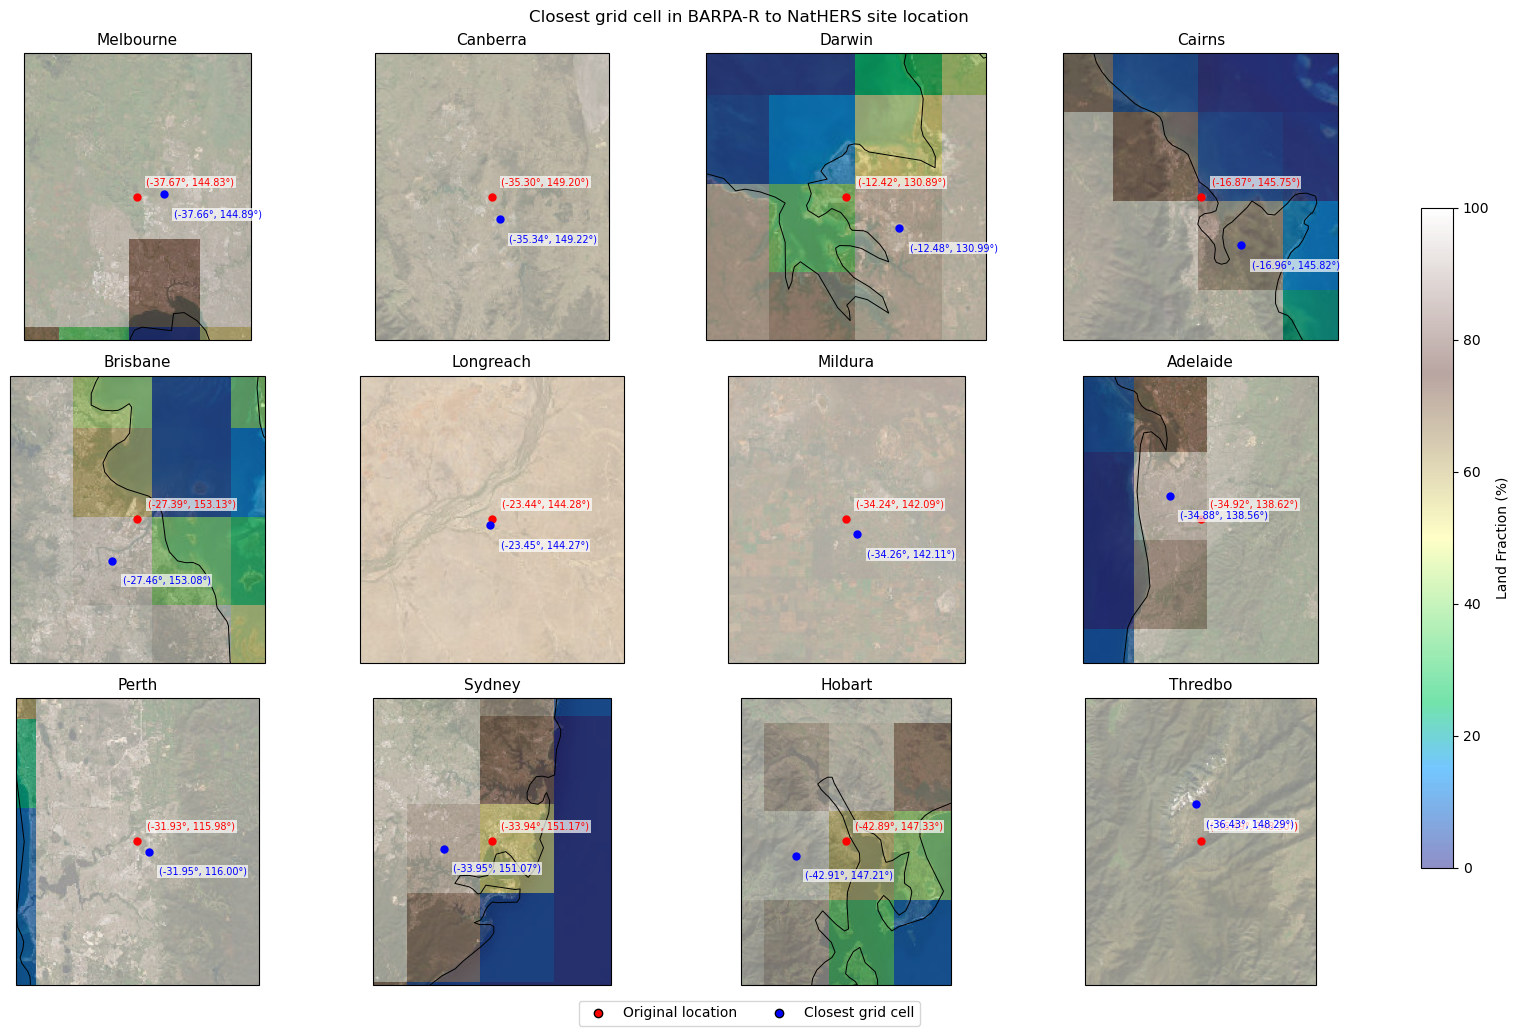

CPU times: user 12.8 s, sys: 405 ms, total: 13.2 s
Wall time: 13.9 s


In [16]:
%%time
land_fraction_threshold = 80 #%

valid_lats = sftlf.lat
valid_lons = sftlf.lon

### Determine closest cell to location with at least 80% land fraction
closest_points = {}

for name, info in locations.items():
    lat0, lon0 = info["Lat"], info["Lon"]

    # distances: DataArray with dims ("lat", "lon")
    distances = utils.great_circle_distance(
        lat0, lon0, valid_lats, valid_lons
    )

    # index of minimum distance (keeps dimension labels)
    land_mask = sftlf >= land_fraction_threshold
    distances = distances.where(land_mask)

    idx = distances.argmin(dim=("lat", "lon"))

    # extract actual coordinates
    closest_lat = distances.lat[idx["lat"]].item()
    closest_lon = distances.lon[idx["lon"]].item()

    closest_points[name] = (closest_lat, closest_lon)

# Create facet plot
num_locs = len(locations)
cols = 4
rows = int(np.ceil(num_locs / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(16, 11),
    subplot_kw={"projection": tile_crs}
)
axes = axes.flatten()

vmin = sftlf.min().item()
vmax = sftlf.max().item()

from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor='red', markersize=6,
           label='Original location'),
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor='blue', markersize=6,
           label='Closest grid cell')
    ]

# Plot each location
# =========================
for ax, (name, info) in zip(axes, locations.items()):

    lat, lon = info["Lat"], info["Lon"]

    zoom = 0.25
    ax.set_extent(
        [lon - zoom, lon + zoom, lat - zoom, lat + zoom],
        crs=ccrs.PlateCarree()
    )

    # Satellite imagery
    ax.add_image(tiler, 9)

    # Land fraction overlay
    im = sftlf.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="terrain",
        vmin=vmin,
        vmax=vmax,
        alpha=0.55,
        add_colorbar=False
    )

    # Features
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)

    # Original location (red)
    ax.plot(
        lon, lat,
        "ro", markersize=5,
        transform=ccrs.PlateCarree()
    )
    
    ax.text(
        lon + 0.02, lat + 0.02,
        fmt_coord(lat, lon),
        fontsize=7,
        color="red",
        transform=ccrs.PlateCarree(),
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1)
    )
    
    # Closest grid cell (blue)
    clat, clon = closest_points[name]
    
    ax.plot(
        clon, clat,
        "bo", markersize=5,
        transform=ccrs.PlateCarree()
    )
    
    ax.text(
        clon + 0.02, clat - 0.04,
        fmt_coord(clat, clon),
        fontsize=7,
        color="blue",
        transform=ccrs.PlateCarree(),
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1)
    )

    ax.set_title(name, fontsize=11)


# =========================
# Remove unused axes
# =========================
for i in range(num_locs, len(axes)):
    fig.delaxes(axes[i])


# =========================
# Colorbar and legend
# =========================
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Land Fraction (%)")

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 0.05)
)

# =========================
# Final layout
# =========================
plt.suptitle(f"Closest grid cell in {barra_v} to NatHERS site location")
plt.tight_layout(rect=[0, 0.08, 0.9, 1])
plt.savefig(
    f"/home/565/dh4185/mn51-dh4185/repos_collab/nesp_bff/plots/{barra_v}_closest_grid_cell_{land_fraction_threshold}landfraction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [51]:
import numpy as np

def dynamic_zoom_extent(lat, lon, clat, clon, *,
                        pad_frac=0.35,
                        min_zoom=0.25,
                        max_zoom=20.0,
                        enforce_square=True):
    """
    Extent that ALWAYS includes both points by centring on the midpoint.
    """

    # Handle lon wrap-around cleanly (important if you ever get near dateline)
    def wrap180(x):
        return (x + 180) % 360 - 180

    lon0 = wrap180(lon)
    clon0 = wrap180(clon)
    if abs(clon0 - lon0) > 180:
        clon0 = clon0 - 360 if clon0 > lon0 else clon0 + 360

    # Centre on midpoint
    lat_c = 0.5 * (lat + clat)
    lon_c = 0.5 * (lon0 + clon0)

    mean_lat = lat_c
    coslat = max(np.cos(np.deg2rad(mean_lat)), 1e-6)

    dlat = abs(clat - lat)
    dlon = abs(clon0 - lon0)

    # Required half spans (midpoint-centred)
    half_lat = 0.5 * dlat
    half_lon = 0.5 * dlon

    # Add padding
    half_lat *= (1 + pad_frac)
    half_lon *= (1 + pad_frac)

    # Clamp (but never below min)
    half_lat = min(max(half_lat, min_zoom), max_zoom)
    half_lon = min(max(half_lon, min_zoom), max_zoom)

    if enforce_square:
        # Make roughly square in distance units
        half = max(half_lat, half_lon * coslat)
        half = min(max(half, min_zoom), max_zoom)
        half_lat = half
        half_lon = half / coslat

    return [lon_c - half_lon, lon_c + half_lon, lat_c - half_lat, lat_c + half_lat]


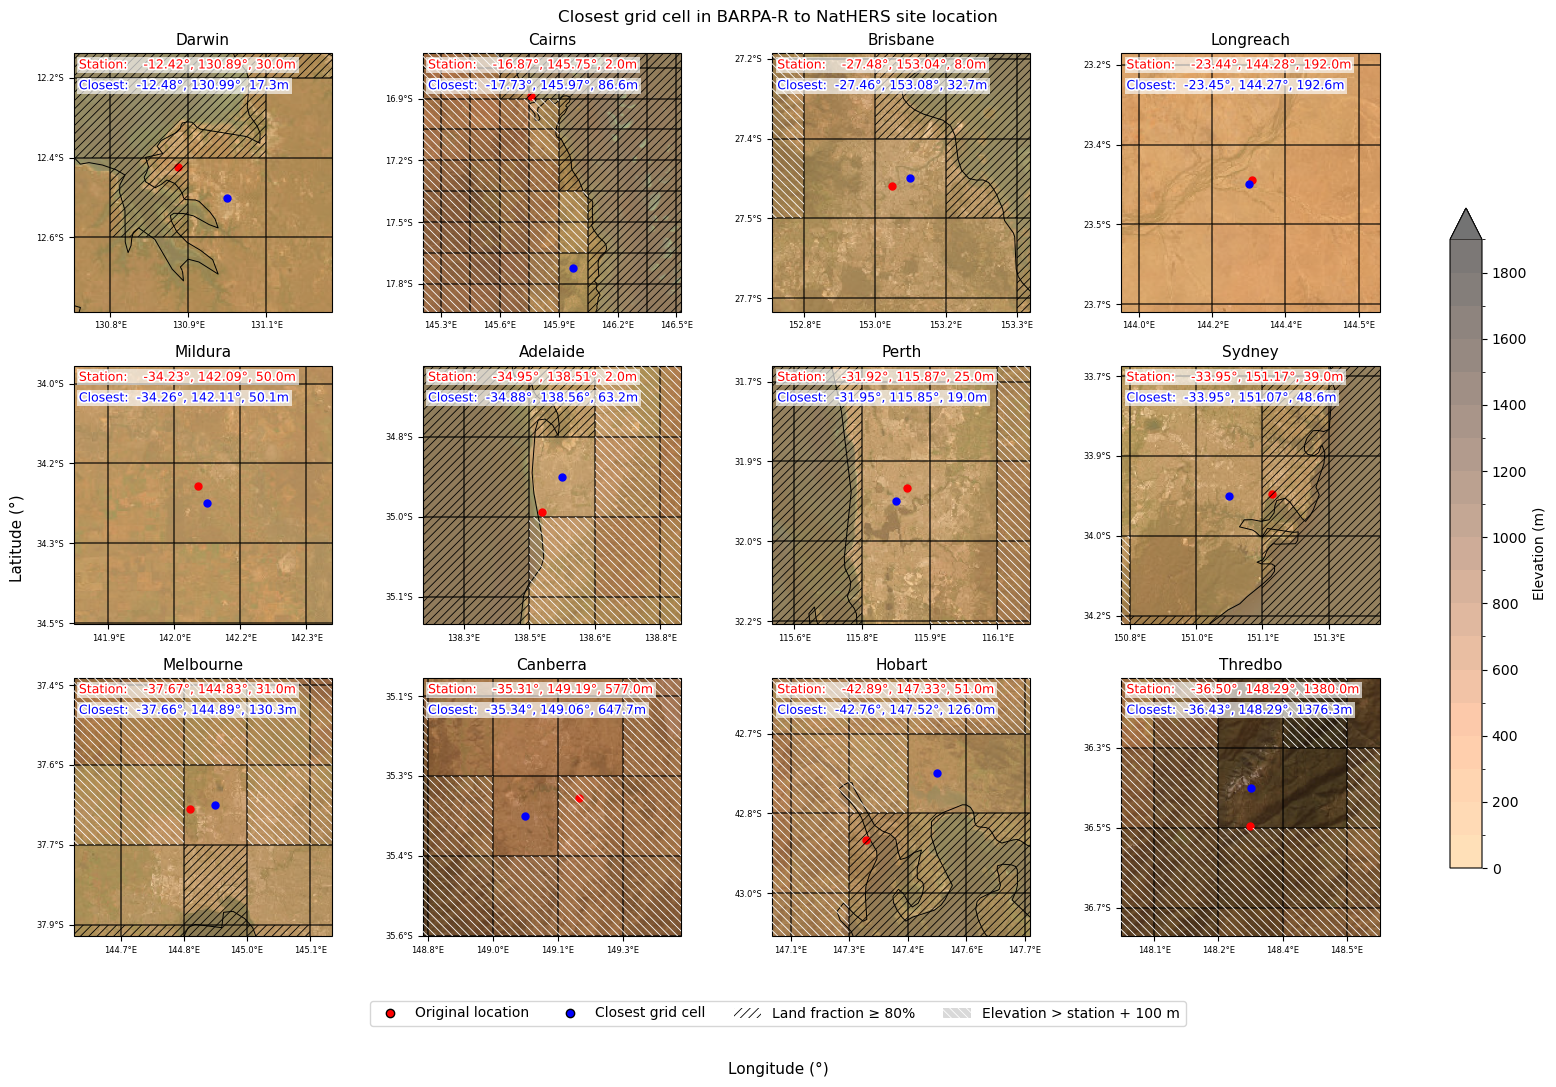

CPU times: user 33.8 s, sys: 806 ms, total: 34.6 s
Wall time: 34.7 s


In [52]:
%%time
# --- Set thresholds for land fraction and elevation tolerance
orog_threshold = 100 # m
land_fraction_threshold = 80 #%
##############################################################

import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

from matplotlib.offsetbox import AnchoredText
import matplotlib.patheffects as pe

import matplotlib.patches as mpatches

import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42   # embed TrueType fonts (editable text)
mpl.rcParams["ps.fonttype"]  = 42
mpl.rcParams["svg.fonttype"] = "none"  # keep text as text in SVG
mpl.rcParams["hatch.linewidth"] = 0.6  # crisper hatch strokes


def hatch_gridcells_exact(
    ax,
    mask_da,            # xarray DataArray (lat, lon) boolean
    lon_b, lat_b,       # 1D bounds arrays (len = n+1)
    extent,             # (lon_min, lon_max, lat_min, lat_max)
    *,
    hatch="////",
    hatch_color="k",
    facecolor="none",
    alpha=1.0,
    zorder=6,
    max_cells=20000,    # safety
):
    """
    Draw exact cell-by-cell hatching using Rectangle patches at cell bounds.
    Uses PlateCarree coordinates.

    Note: this can be slower if you hatch many cells; we clip to the extent.
    """
    lon_min, lon_max, lat_min, lat_max = extent

    # Boolean numpy mask (lat, lon)
    mask = mask_da.values.astype(bool)

    # Indices of True cells
    ii, jj = np.where(mask)

    if ii.size == 0:
        return

    # Clip to current extent using bounds
    # A cell is "in extent" if its bounds overlap the extent at all.
    in_lon = (lon_b[jj] <= lon_max) & (lon_b[jj + 1] >= lon_min)
    in_lat = (lat_b[ii] <= lat_max) & (lat_b[ii + 1] >= lat_min)
    keep = in_lon & in_lat
    ii, jj = ii[keep], jj[keep]

    if ii.size == 0:
        return

    if ii.size > max_cells:
        # Thin if huge (keeps you from accidentally hatching half Australia)
        step = int(np.ceil(ii.size / max_cells))
        ii, jj = ii[::step], jj[::step]

    # Temporarily set hatch colour (works reliably across backends)
    import matplotlib as mpl
    prev_hatch_color = mpl.rcParams.get("hatch.color", "k")
    mpl.rcParams["hatch.color"] = hatch_color

    # Add patches
    for i, j in zip(ii, jj):
        x0, x1 = lon_b[j], lon_b[j + 1]
        y0, y1 = lat_b[i], lat_b[i + 1]
        rect = mpatches.Rectangle(
            (x0, y0),
            x1 - x0,
            y1 - y0,
            facecolor=facecolor,
            edgecolor=hatch_color,   # hatch colour follows hatch.color, but edgecolor helps legend/consistency
            linewidth=0.0,
            hatch=hatch,
            alpha=alpha,
            transform=ccrs.PlateCarree(),
            zorder=zorder,
        )
        ax.add_patch(rect)

    mpl.rcParams["hatch.color"] = prev_hatch_color

def add_location_box(ax, orig, closest, *, fontsize=10):
    """
    orig, closest are (lat, lon). Adds a 2-line colour-coded box in top-left.
    """
    lat, lon, elev = orig
    clat, clon, celev = closest

    # Build two coloured lines using separate texts so each can have its own colour
    # We'll place them using axes coordinates (0-1), so they never overlap with map content.
    x, y = 0.02, 0.98  # top-left in axes coords

    # White halo for readability
    halo = [pe.withStroke(linewidth=2.5, foreground="white")]

    ax.text(
        x, y,
        f"Station:    {fmt_coord(lat, lon, elev)}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        color="red",
        path_effects=halo,
        bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=1.2),
        zorder=10
    )
    ax.text(
        x, y - 0.08,
        f"Closest:  {fmt_coord(clat, clon, celev)}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        color="blue",
        path_effects=halo,
        bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=1.2),
        zorder=10
    )

valid_lats = orog.lat
valid_lons = orog.lon

### Determine closest cell to location within XX of elevation
closest_points = {}

for name, info in locations.items():
    lat0, lon0, elev0 = info["Lat"], info["Lon"], info["Elev"]

    # distances: DataArray with dims ("lat", "lon")
    distances = utils.great_circle_distance(
        lat0, lon0, valid_lats, valid_lons
    )

    # index of minimum distance (keeps dimension labels)
    land_mask = (orog > 0) & (orog <= elev0 + orog_threshold) & (sftlf >= land_fraction_threshold)
    distances = distances.where(land_mask)

    idx = distances.argmin(dim=("lat", "lon"))

    # extract actual coordinates
    closest_lat = distances.lat[idx["lat"]].item()
    closest_lon = distances.lon[idx["lon"]].item()

    closest_points[name] = (closest_lat, closest_lon)

# Create facet plot
num_locs = len(locations)
cols = 4
rows = int(np.ceil(num_locs / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(16, 11),
    subplot_kw={"projection": tile_crs}
)
axes = axes.flatten()

vmin = orog.min().item()
vmax = orog.max().item()

from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor='red', markersize=6,
           label='Original location'),
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor='blue', markersize=6,
           label='Closest grid cell')
    ]

# Plot each location
# =========================
for ax, (name, info) in zip(axes, locations.items()):

    lat, lon, elev = info["Lat"], info["Lon"], info["Elev"]

    clat, clon = closest_points[name]
    celev = orog.sel(lat=clat,lon=clon).item()

    extent = dynamic_zoom_extent(
        lat, lon, clat, clon,
        pad_frac=0.5,#35,
        min_zoom=0.25,   # keep your old behaviour as a minimum
        max_zoom=20.0     # adjust if you want
    )

    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Satellite imagery
    ax.add_image(tiler, 9)
    # cartopy tiles are raster; ensure they rasterize cleanly in vector export
    for art in ax.get_images():
        art.set_rasterized(True)


    # Land fraction overlay
    im = orog.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="copper_r",#"terrain",
        levels=np.arange(0,2000,100),
        # vmin=vmin,
        # vmax=vmax,
        alpha=0.55,
        add_colorbar=False
    )
    # Keep terrain as raster inside vector output (huge size win)
    try:
        im.set_rasterized(True)
    except Exception:
        pass

    # --- Visualise the grid: draw cell edges (no fill) ---
    # Build approximate cell edges from 1D centres
    def coord_bounds_1d(c):
        c = np.asarray(c, dtype=float)
        dc = np.diff(c)
        edges = np.empty(c.size + 1, dtype=float)
        edges[1:-1] = c[:-1] + 0.5 * dc
        edges[0] = c[0] - 0.5 * dc[0]
        edges[-1] = c[-1] + 0.5 * dc[-1]
        return edges
    
    lon_b = coord_bounds_1d(orog.lon.values)
    lat_b = coord_bounds_1d(orog.lat.values)
    
    # Dummy Z just to get a QuadMesh; we only draw edges
    Z = np.zeros((orog.lat.size, orog.lon.size))
    
    grid_qm=ax.pcolormesh(
        lon_b, lat_b, Z,
        transform=ccrs.PlateCarree(),
        shading="flat",
        facecolor="none",
        edgecolor="k",
        linewidth=0.15,     # tweak: 0.1–0.25
        alpha=0.35,         # tweak: 0.2–0.5
        zorder=2
    )
    grid_qm.set_rasterized(True)

    land_mask_plot = (sftlf < land_fraction_threshold)
    
    hatch_gridcells_exact(
        ax,
        land_mask_plot,
        lon_b, lat_b,
        extent,
        hatch="////",
        hatch_color="k",
        facecolor="none",
        zorder=5
    )

    # --- Hatch cells that fail elevation criterion ---
    
    lower = max(0, elev - orog_threshold)
    upper = elev + orog_threshold
    
    elev_fail = (
        (sftlf >= land_fraction_threshold)
        & ((orog < lower) | (orog > upper))
    )

    hatch_gridcells_exact(
        ax,
        elev_fail,
        lon_b, lat_b,
        extent,
        hatch="\\\\\\\\",
        hatch_color="white",
        facecolor="none",
        zorder=6
    )

    # Features
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    # gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.6, alpha=0.35)
    # gl.top_labels = False
    # gl.right_labels = False
    # gl.xlabel_style = {"size": 6}
    # gl.ylabel_style = {"size": 6}
    # --- Align ticks with model grid ---
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    
    lon_min, lon_max, lat_min, lat_max = extent
    
    # Grid *edges* (bounds)
    lon_edges = lon_b
    lat_edges = lat_b
    
    # Keep only edges inside the current extent (allow a tiny margin)
    eps = 1e-9
    lon_ticks = lon_edges[(lon_edges >= lon_min - eps) & (lon_edges <= lon_max + eps)]
    lat_ticks = lat_edges[(lat_edges >= lat_min - eps) & (lat_edges <= lat_max + eps)]
    
    # Thin so you don't get a picket fence (aim ~4–6 ticks)
    target = 5
    if len(lon_ticks) > target:
        step = max(1, int(np.ceil(len(lon_ticks) / target)))
        lon_ticks = lon_ticks[::step]
    if len(lat_ticks) > target:
        step = max(1, int(np.ceil(len(lat_ticks) / target)))
        lat_ticks = lat_ticks[::step]
    
    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Format labels nicely
    ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.1f',))
    ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.1f',))
    
    ax.tick_params(labelsize=6)


    # Original location (red)
    ax.plot(
        lon, lat,
        "ro", markersize=5,
        transform=ccrs.PlateCarree()
    )
    
    # Closest grid cell (blue)
    clat, clon = closest_points[name]
    
    ax.plot(
        clon, clat,
        "bo", markersize=5,
        transform=ccrs.PlateCarree()
    )

    add_location_box(ax, (lat, lon, elev), (clat, clon, celev), fontsize=9)
    ax.set_title(name, fontsize=11)


# =========================
# Remove unused axes
# =========================
for i in range(num_locs, len(axes)):
    fig.delaxes(axes[i])


# =========================
# Colorbar and legend
# =========================
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Elevation (m)")

import matplotlib.patches as mpatches

land_patch = mpatches.Patch(
    facecolor="none",
    hatch="////",
    label=f"Land fraction ≥ {land_fraction_threshold}%"
)
legend_handles.append(land_patch)

elev_patch = mpatches.Patch(
    facecolor="#d9d9d9",        # light grey background
    hatch="\\\\\\\\",
    edgecolor="white",
    linewidth=0.0,
    label=f"Elevation > station + {orog_threshold} m"
)
legend_handles.append(elev_patch)

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=4,
    frameon=True,
    bbox_to_anchor=(0.5, 0.05)
)

# =========================
# Final layout
# =========================
fig.supxlabel("Longitude (°)", fontsize=11)
fig.supylabel("Latitude (°)", fontsize=11)

plt.suptitle(f"Closest grid cell in {barra_v} to NatHERS site location")
plt.tight_layout(rect=[0, 0.08, 0.9, 1])
out_base = f"/home/565/dh4185/mn51-dh4185/repos_collab/nesp_bff/plots/{barra_v}_closest_grid_cell_{orog_threshold}m_elevation"

plt.savefig(
    f"{out_base}.png",
    dpi=300,
    bbox_inches="tight"
)

import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

# Vector PDF with rasterized heavy layers
plt.savefig(
    f"{out_base}.pdf",
    bbox_inches="tight",
    dpi=300,                 # DPI for rasterized parts only
    metadata={"Creator": "matplotlib"}
)

# # SVG (can get large with many hatches, but still works well)
# plt.savefig(
#     f"{out_base}.svg",
#     bbox_inches="tight",
#     dpi=300
# )

plt.show()


### Step1: Checking extracted output

In [5]:
file_dir = "/g/data/eg3/nesp_bff/"

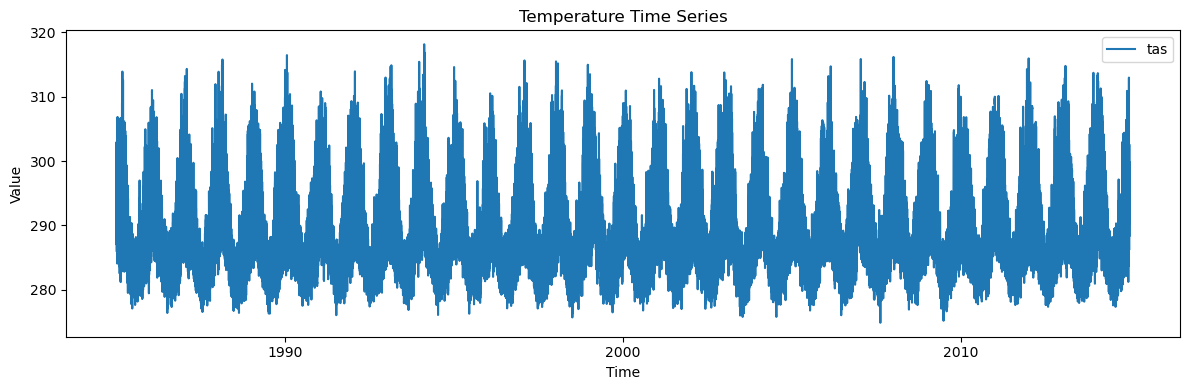

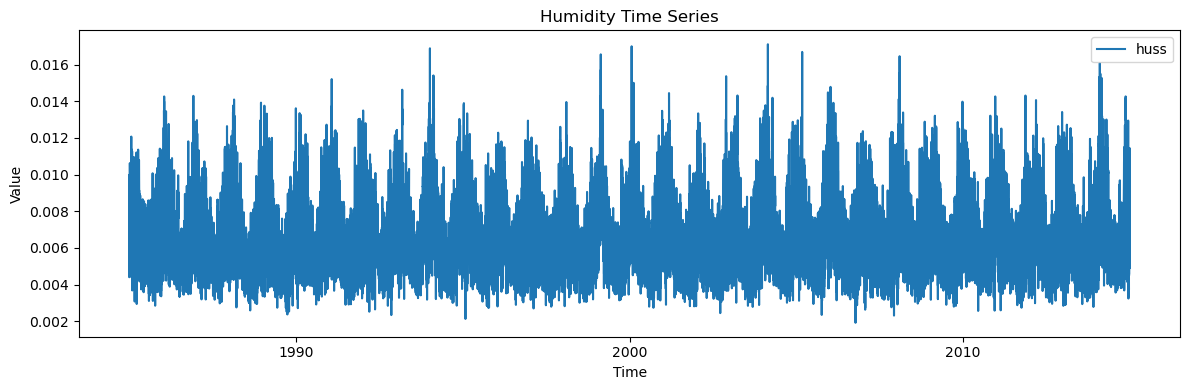

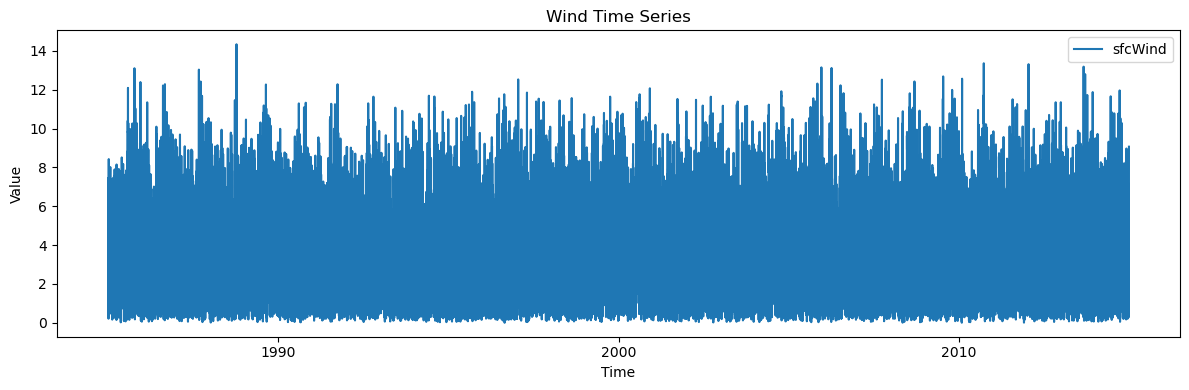

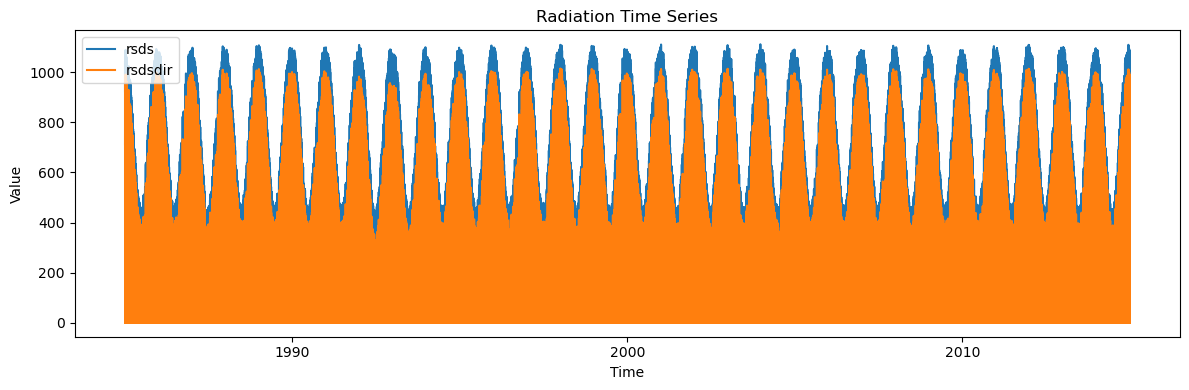

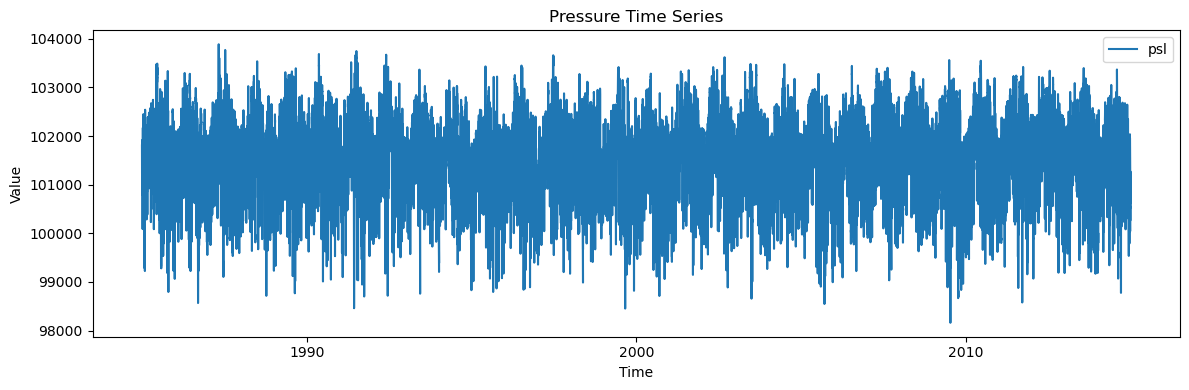

In [20]:
ds_hist = xr.open_dataset(f"{file_dir}step1_raw_data_extraction//BARPA-R/Melbourne_AUS-15_CMCC-ESM2_historical_r1i1p1f1_BOM_BARPA-R_v1-r1_1hr_1985-2014.nc")
ds_2050 = xr.open_dataset(f"{file_dir}step1_raw_data_extraction//BARPA-R/Melbourne_AUS-15_CMCC-ESM2_ssp370_r1i1p1f1_BOM_BARPA-R_v1-r1_1hr_2035-2064.nc")


plot_groups = {
    'Temperature': ['tas'],
    'Humidity': ['huss'],
    'Wind': ['sfcWind', 'sfcWindmax'],
    'Radiation': ['rsds', 'rsdsdir'],
    'Pressure': ['psl']
}

# Create individual plots
for title, vars in plot_groups.items():
    plt.figure(figsize=(12, 4))
    for var in vars:
        if var in ds_hist:
            ds_hist[var].plot(label=var)
    plt.title(f'{title} Time Series')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.tight_layout()
    plt.show()


### Check hourly data

0


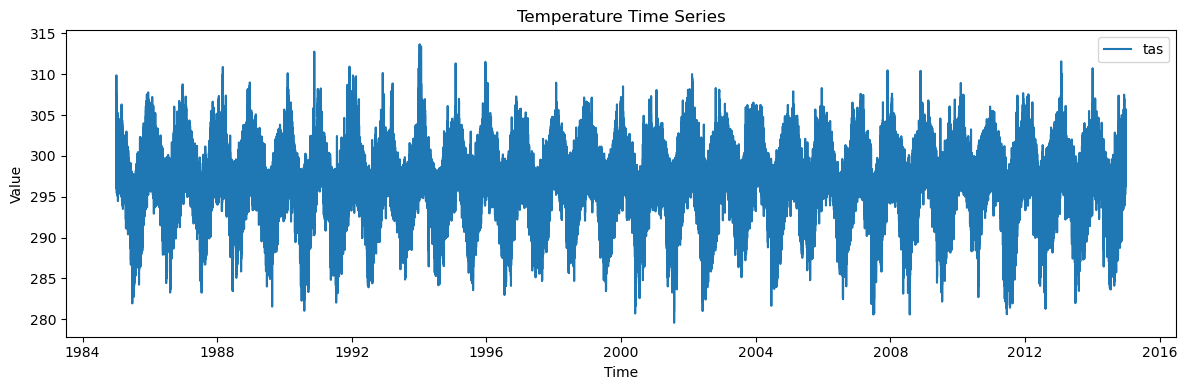

0
0


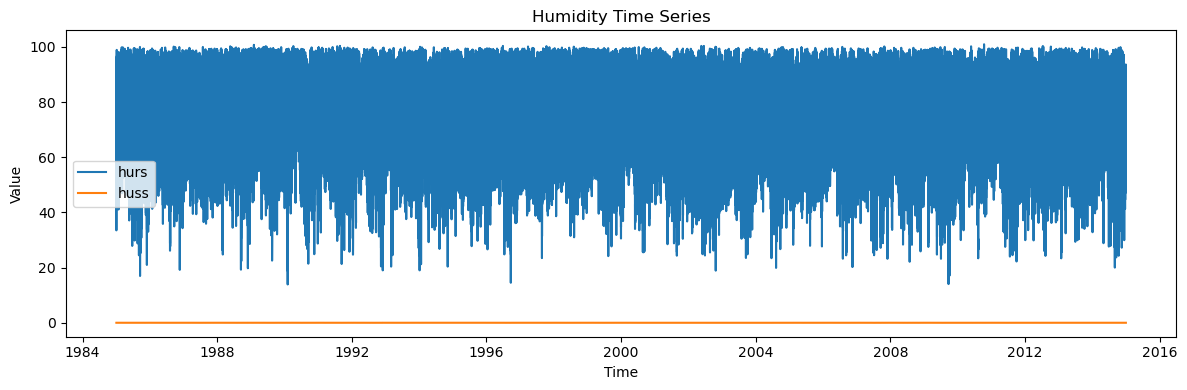

0
0
0


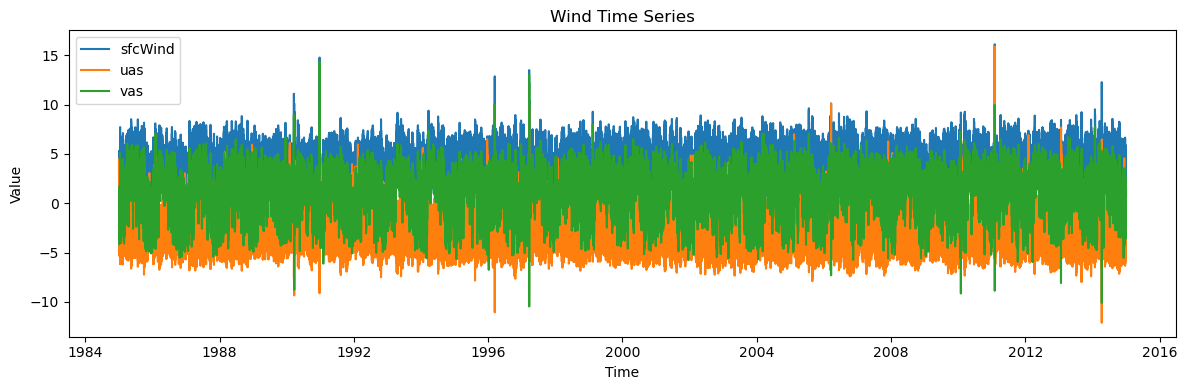

0
0
0


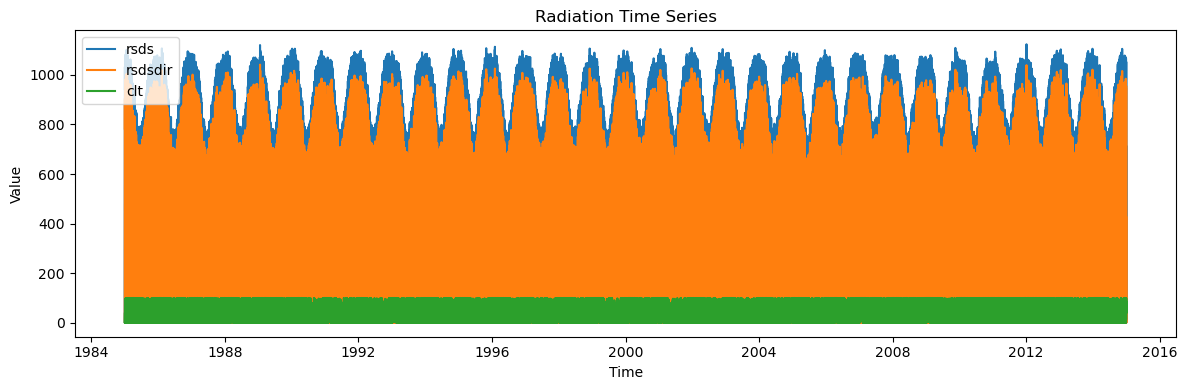

0


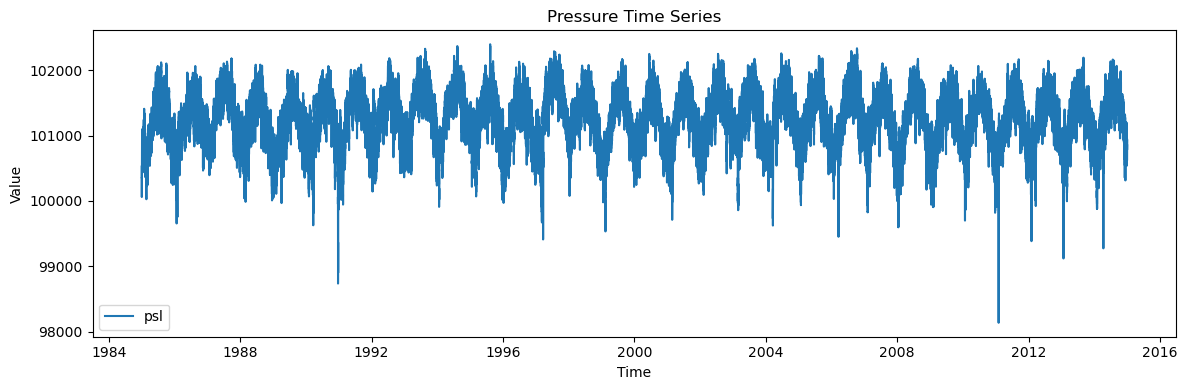

In [4]:
import matplotlib.pyplot as plt
da_var = ['tas','hurs','huss','sfcWind','psl','uas','vas','clt','rsds','rsdsdir']

ds_hist = xr.open_dataset(f"{file_dir}step1_raw_data_extraction/BARRA-R2/Cairns_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_1hr_1985-2014.nc")
ds_hist# ds_2050 = xr.open_dataset(f"{file_dir}step1_raw_data_extraction//BARPA-R/Melbourne_AUS-15_CMCC-ESM2_ssp370_r1i1p1f1_BOM_BARPA-R_v1-r1_day_2041-2060.nc")


plot_groups = {
    'Temperature': ['tas'],
    'Humidity': ['hurs', 'huss'],
    'Wind': ['sfcWind', 'uas', 'vas'],
    'Radiation': ['rsds', 'rsdsdir', 'clt'],
    'Pressure': ['psl']
}

# Create individual plots
for title, vars in plot_groups.items():
    plt.figure(figsize=(12, 4))
    for var in vars:
        if var in ds_hist:
            ds_hist[var].plot(label=var)
            print(ds_hist[var].isnull().sum(dim="time").values)
    plt.title(f'{title} Time Series')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [11]:
da_var = ['tas','hurs','huss','sfcWind','psl','uas','vas','clt','rsds','rsdsdir']
gcms = ['ACCESS-ESM1-5','ACCESS-CM2','MPI-ESM1-2-HR','CMCC-ESM','EC-Earth3','CESM2','NorESM2-MM']

for gcm in gcms:
    print(f"------ {gcm} ------")
    file = glob.glob(f"{file_dir}step1_raw_data_extraction/BARPA-R/Cairns*{gcm}*ssp370*1hr*.nc")[0]
    print(file)
    ds_hist = xr.open_dataset(file)
    for var in da_var:
        if var in ds_hist:
            # ds_hist[var].plot(label=var)
            nans = ds_hist[var].isnull().sum(dim="time").values
            print(f"Number of NaNs in {var}: {nans}")


------ ACCESS-ESM1-5 ------
/g/data/eg3/nesp_bff/step1_raw_data_extraction/BARPA-R/Cairns_AUS-15_ACCESS-ESM1-5_ssp370_r6i1p1f1_BOM_BARPA-R_v1-r1_1hr_2035-2064.nc
Number of NaNs in tas: 0
Number of NaNs in hurs: 0
Number of NaNs in huss: 0
Number of NaNs in sfcWind: 0
Number of NaNs in psl: 0
Number of NaNs in uas: 0
Number of NaNs in vas: 0
Number of NaNs in clt: 0
Number of NaNs in rsds: 0
Number of NaNs in rsdsdir: 0
------ ACCESS-CM2 ------
/g/data/eg3/nesp_bff/step1_raw_data_extraction/BARPA-R/Cairns_AUS-15_ACCESS-CM2_ssp370_r4i1p1f1_BOM_BARPA-R_v1-r1_1hr_2035-2064.nc
Number of NaNs in tas: 0
Number of NaNs in hurs: 0
Number of NaNs in huss: 0
Number of NaNs in sfcWind: 0
Number of NaNs in psl: 0
Number of NaNs in uas: 0
Number of NaNs in vas: 0
Number of NaNs in clt: 0
Number of NaNs in rsds: 0
Number of NaNs in rsdsdir: 0
------ MPI-ESM1-2-HR ------
/g/data/eg3/nesp_bff/step1_raw_data_extraction/BARPA-R/Cairns_AUS-15_MPI-ESM1-2-HR_ssp370_r1i1p1f1_BOM_BARPA-R_v1-r1_1hr_2035-2064.n

### Step 2: Checking QDC daily and hourly output

Number of NaNs in tas: 0


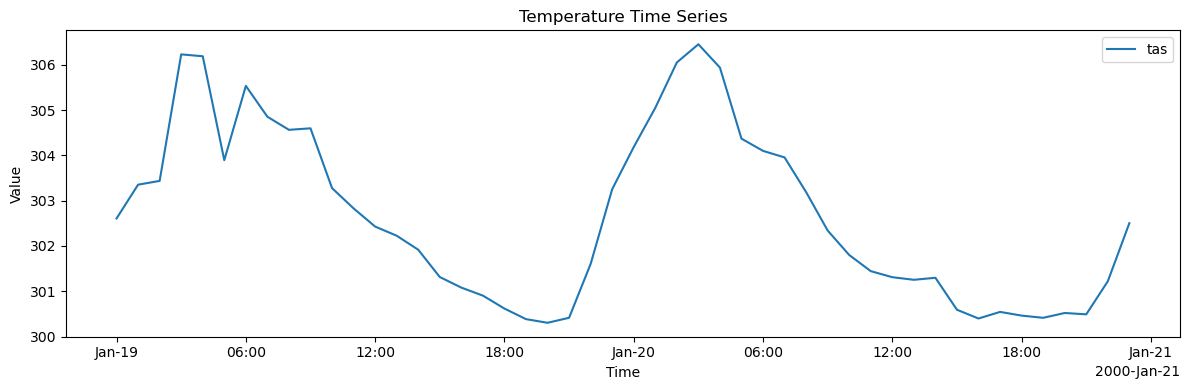

Number of NaNs in huss: 0
Number of NaNs in hurs: 0


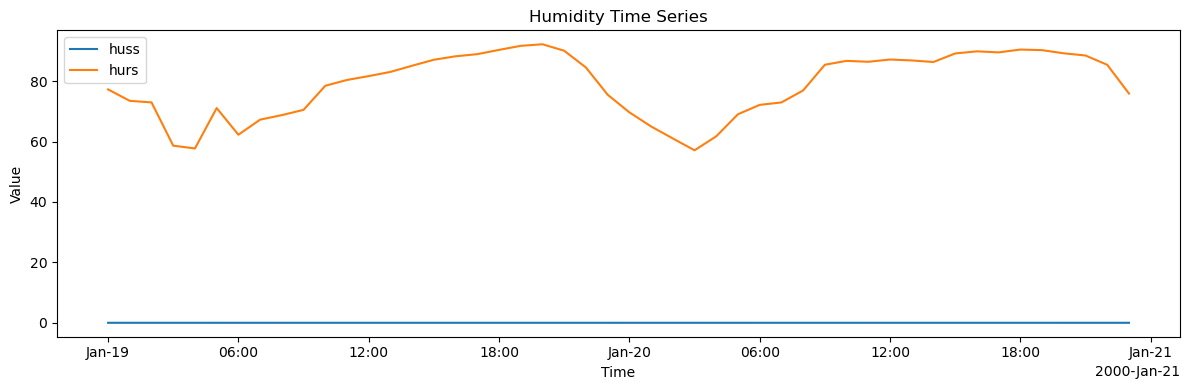

Number of NaNs in sfcWind: 0
Number of NaNs in vas: 0
Number of NaNs in uas: 0


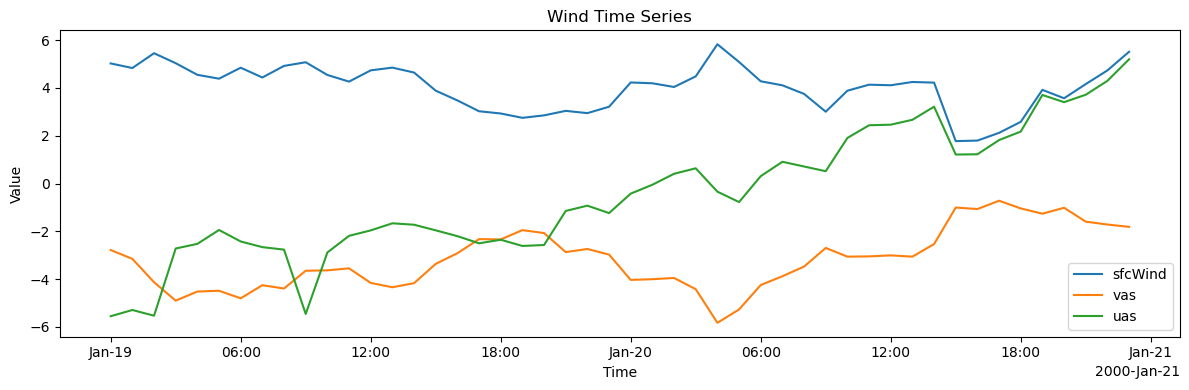

Number of NaNs in rsds: 0
Number of NaNs in rsdsdir: 0


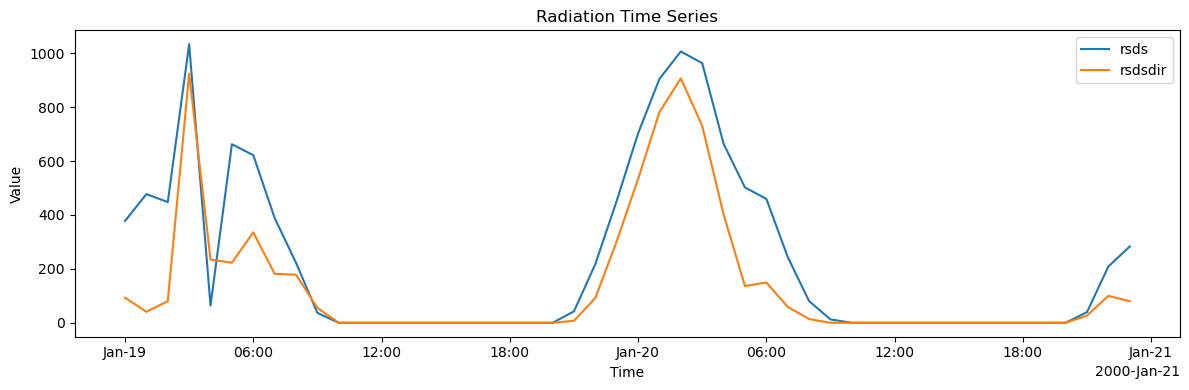

Number of NaNs in psl: 0


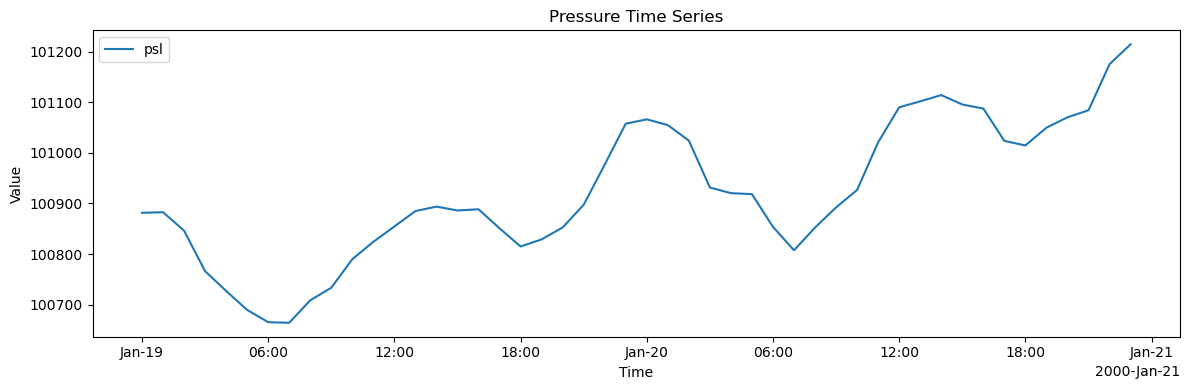

Number of NaNs in clt: 0


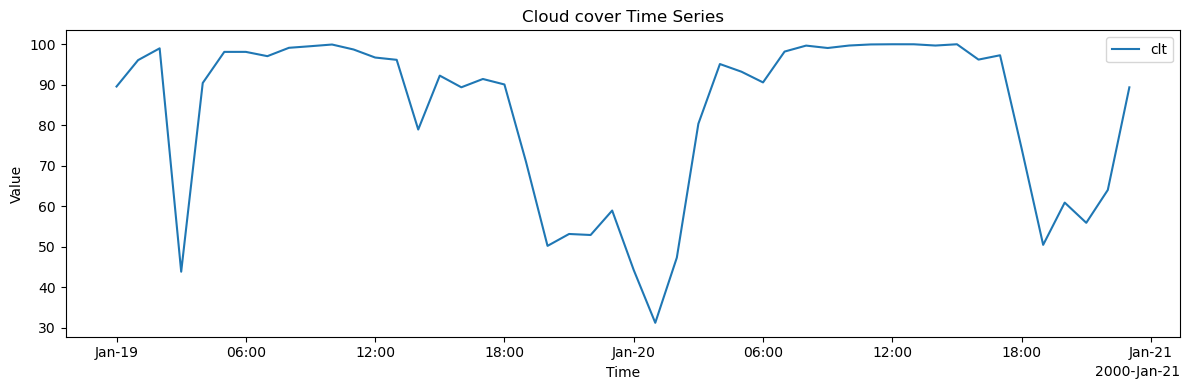

In [28]:
ds_adjust = xr.open_dataset(f"{file_dir}step2_qdc_scaling/BARPA-R/Darwin_AUS-15_ACCESS-ESM1-5_ssp370_r6i1p1f1_BOM_BARPA-R_v1-r1_1hr_2050_QDC-BARRAR2.nc")
# ds_2050 = xr.open_dataset(f"{file_dir}step2_qdc_scaling/BARPA-R/Darwin_AUS-15_ACCESS-CM2_ssp370_r4i1p1f1_BOM_BARPA-R_v1-r1_1hr_2050_QDC-BARRAR2.nc")
ds_adjust = ds_adjust.sel(time=slice("19-01-2000","20-01-2000"))

plot_groups = {
    'Temperature': ['tas'],
    'Humidity': ['huss','hurs'],
    'Wind': ['sfcWind','vas','uas'],
    'Radiation': ['rsds', 'rsdsdir'],
    'Pressure': ['psl'],
    'Cloud cover': ['clt']
}

# Create individual plots
for title, vars in plot_groups.items():
    plt.figure(figsize=(12, 4))
    for var in vars:
        if var in ds_adjust:
            nans = ds_adjust[var].isnull().sum(dim="time").values
            print(f"Number of NaNs in {var}: {nans}")
            ds_adjust[var].plot(label=var)
    plt.title(f'{title} Time Series')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.tight_layout()
    plt.show()


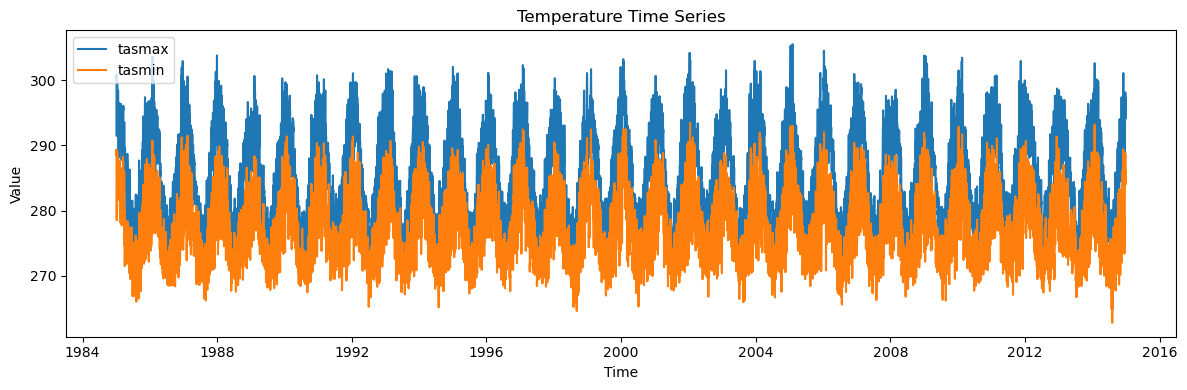

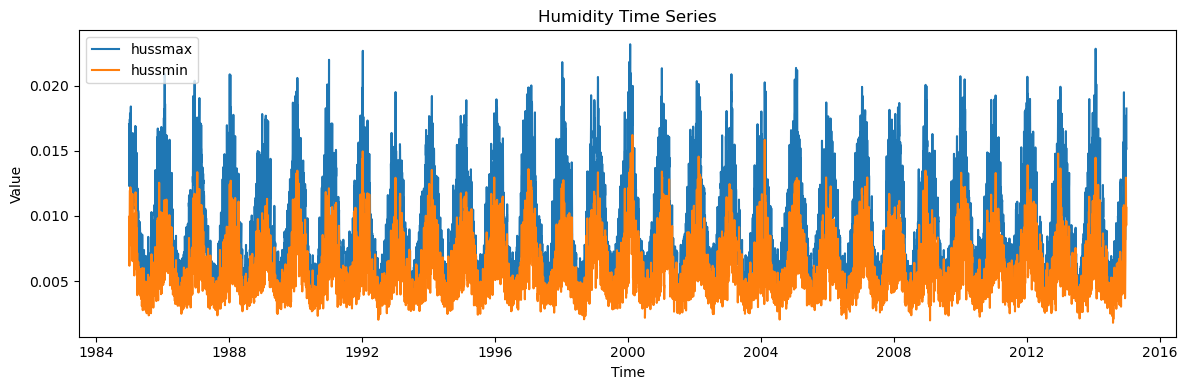

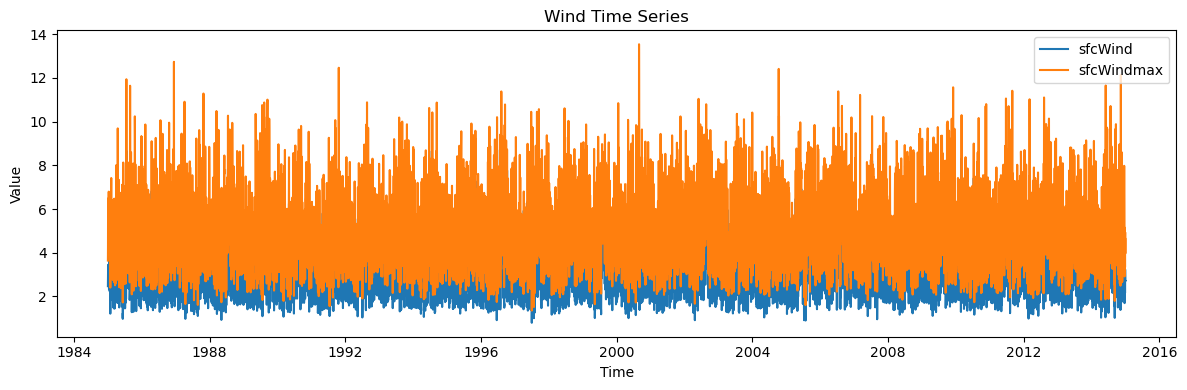

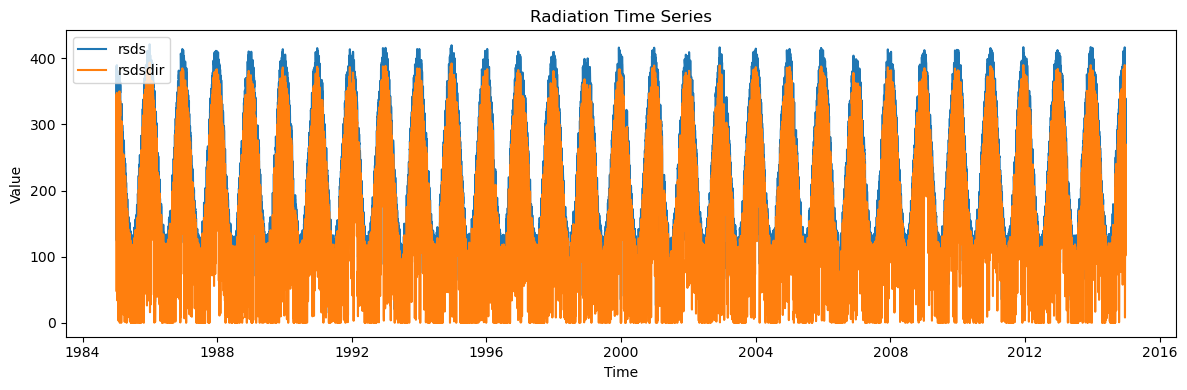

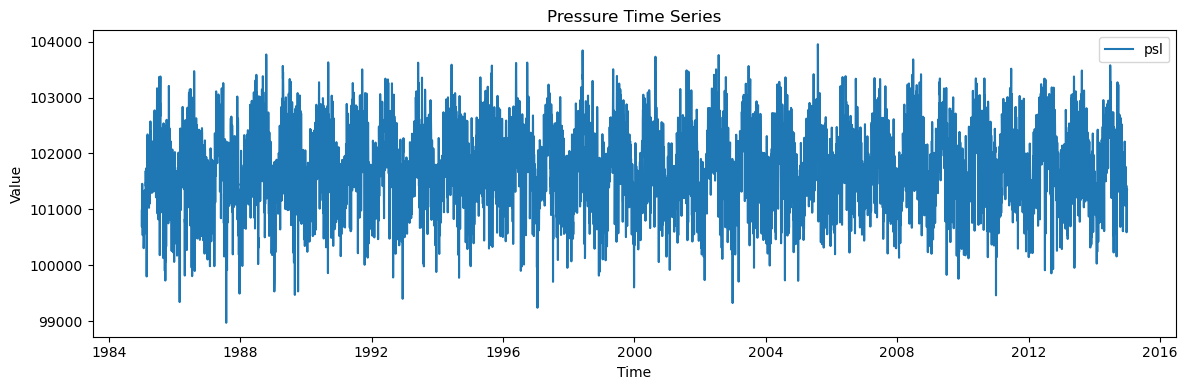

In [11]:
ds_hist = xr.open_dataset(f"{file_dir}step1_raw_data_extraction/CSIRO-CCAM/Thredbo_AUS-10i_ACCESS-ESM1-5_historical_r6i1p1f1_CSIRO_CCAM-v2203-SN_v1-r1_day_1985-2014.nc")
ds_hist_barra = xr.open_dataset(f"{file_dir}step1_raw_data_extraction/BARRA-R2/Thredbo_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_day_1985-2014.nc")

plot_groups = {
    'Temperature': ['tasmax','tasmin'],
    'Humidity': ['hussmax','hussmin'],
    'Wind': ['sfcWind', 'sfcWindmax'],
    'Radiation': ['rsds', 'rsdsdir'],
    'Pressure': ['psl']
}

# Create individual plots
for title, vars in plot_groups.items():
    plt.figure(figsize=(12, 4))
    for var in vars:
        if var in ds_hist:
            ds_hist[var].plot(label=var)
    plt.title(f'{title} Time Series')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.tight_layout()
    plt.show()

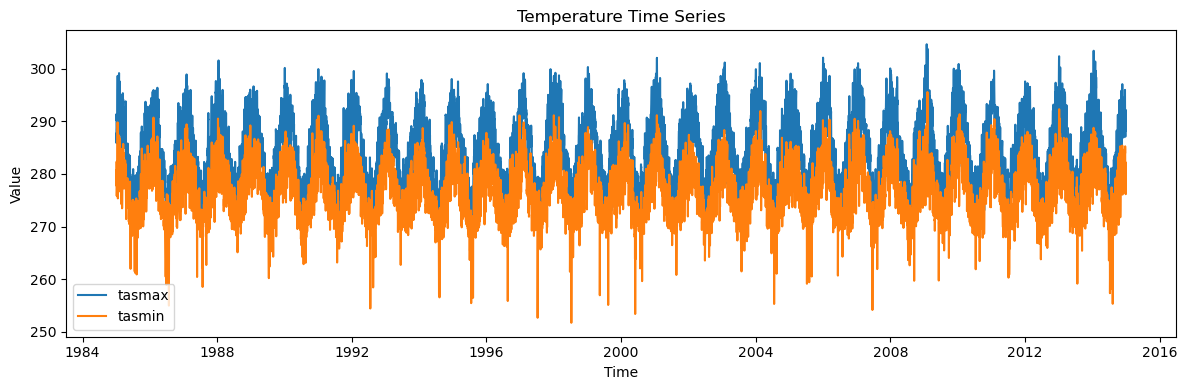

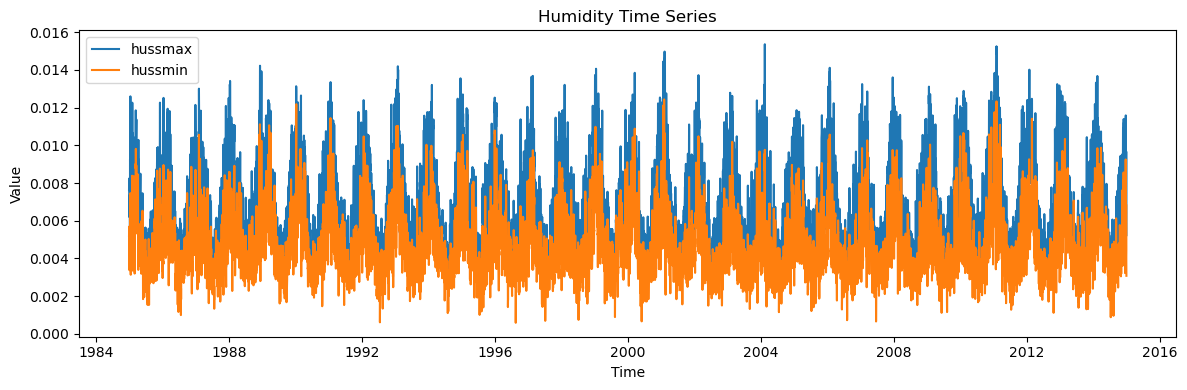

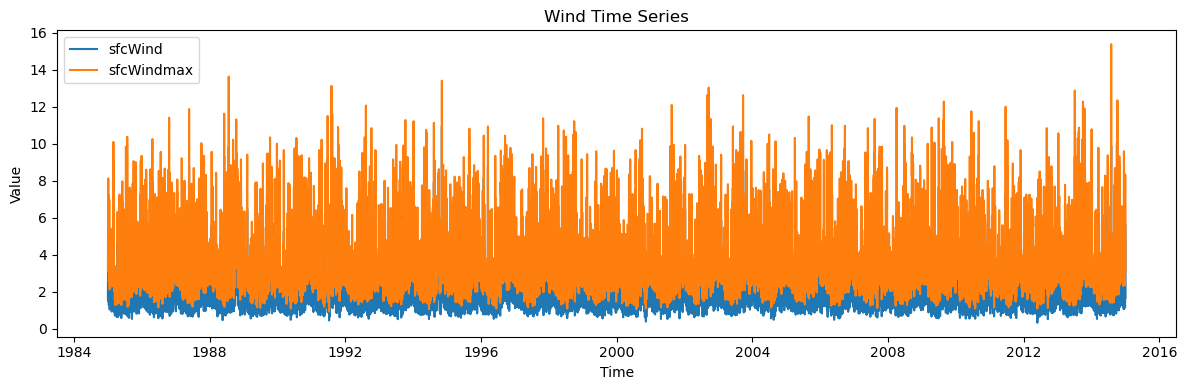

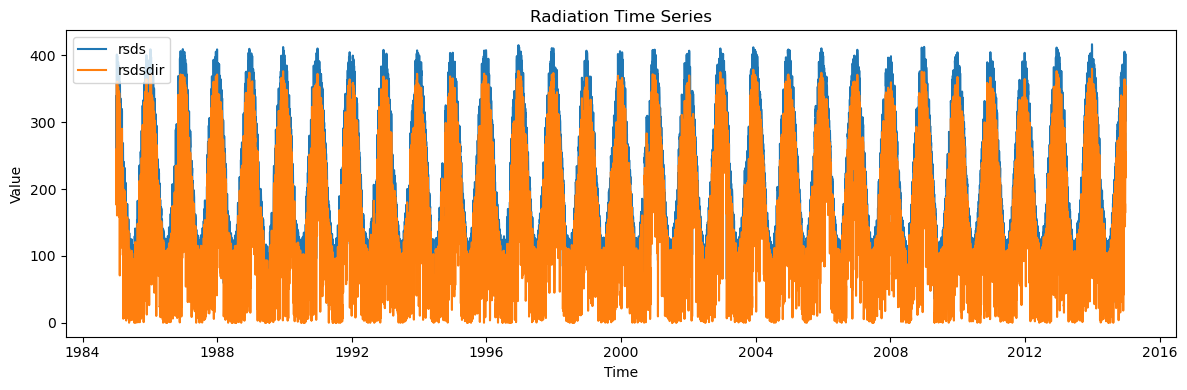

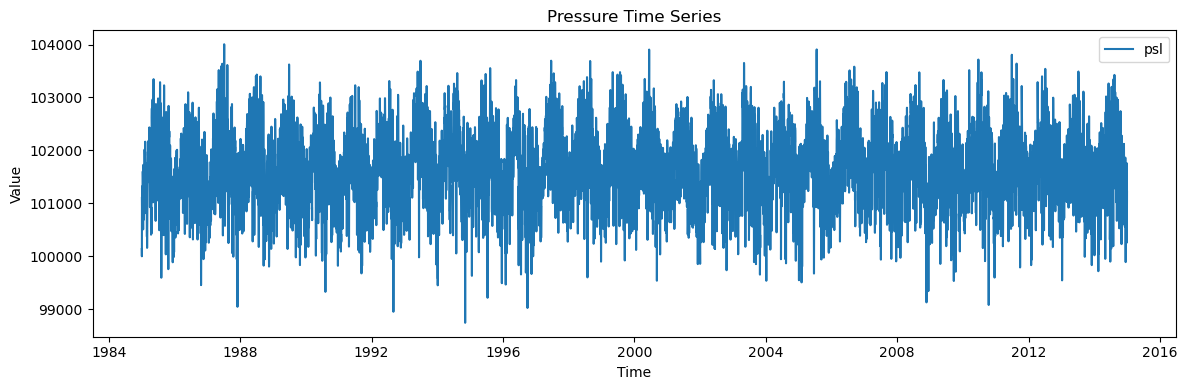

In [12]:
plot_groups = {
    'Temperature': ['tasmax','tasmin'],
    'Humidity': ['hussmax','hussmin'],
    'Wind': ['sfcWind', 'sfcWindmax'],
    'Radiation': ['rsds', 'rsdsdir'],
    'Pressure': ['psl']
}

# Create individual plots
for title, vars in plot_groups.items():
    plt.figure(figsize=(12, 4))
    for var in vars:
        if var in ds_hist_barra:
            ds_hist_barra[var].plot(label=var)
    plt.title(f'{title} Time Series')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [7]:
a = xr.open_dataset("/g/data/eg3/nesp_bff/step1_raw_data_extraction/CSIRO-CCAM/Cairns_AUS-10i_NorESM2-MM_historical_r1i1p1f1_CSIRO_CCAM-v2203-SN_v1-r1_1hr_1985-2014.nc")
a#.tas.plot()

<xarray.Dataset> Size: 25MB
Dimensions:  (time: 525600)
Coordinates:
  * time     (time) object 4MB 1985-01-01 00:00:00 ... 2014-12-31 23:30:00
    lon      float64 8B ...
    lat      float64 8B ...
Data variables:
    tas      (time) float32 2MB ...
    hurs     (time) float32 2MB ...
    huss     (time) float32 2MB ...
    sfcWind  (time) float32 2MB ...
    psl      (time) float32 2MB ...
    uas      (time) float32 2MB ...
    vas      (time) float32 2MB ...
    clt      (time) float32 2MB ...
    rsds     (time) float32 2MB ...
    rsdsdir  (time) float32 2MB ...

In [10]:
ds = xr.open_dataset("/g/data/eg3/nesp_bff/step1_raw_data_extraction/BARRA-R2/Darwin_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_30min_1995-2014.nc")
ds.tas.sel(time="2014-12-31").values
ds.time.sel(time="2014-12-31").values

array(['2014-12-31T00:00:00.000000000', '2014-12-31T00:30:00.000000000',
       '2014-12-31T01:00:00.000000000', '2014-12-31T01:30:00.000000000',
       '2014-12-31T02:00:00.000000000', '2014-12-31T02:30:00.000000000',
       '2014-12-31T03:00:00.000000000', '2014-12-31T03:30:00.000000000',
       '2014-12-31T04:00:00.000000000', '2014-12-31T04:30:00.000000000',
       '2014-12-31T05:00:00.000000000', '2014-12-31T05:30:00.000000000',
       '2014-12-31T06:00:00.000000000', '2014-12-31T06:30:00.000000000',
       '2014-12-31T07:00:00.000000000', '2014-12-31T07:30:00.000000000',
       '2014-12-31T08:00:00.000000000', '2014-12-31T08:30:00.000000000',
       '2014-12-31T09:00:00.000000000', '2014-12-31T09:30:00.000000000',
       '2014-12-31T10:00:00.000000000', '2014-12-31T10:30:00.000000000',
       '2014-12-31T11:00:00.000000000', '2014-12-31T11:30:00.000000000',
       '2014-12-31T12:00:00.000000000', '2014-12-31T12:30:00.000000000',
       '2014-12-31T13:00:00.000000000', '2014-12-31

Number of NaNs in tas: 1


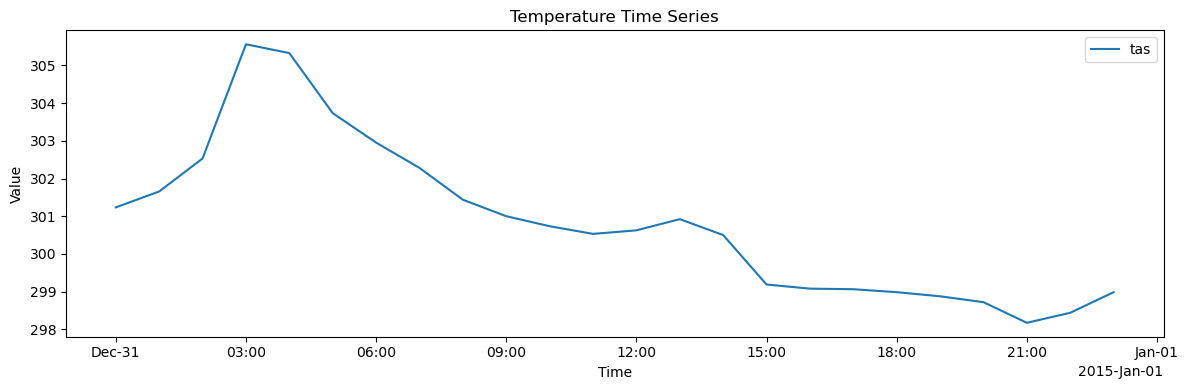

Number of NaNs in huss: 1
Number of NaNs in hurs: 1


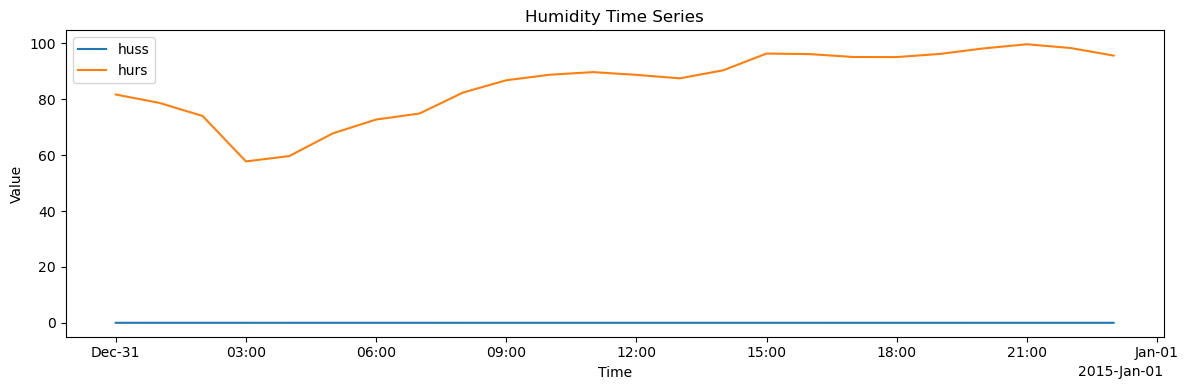

Number of NaNs in sfcWind: 1
Number of NaNs in vas: 1
Number of NaNs in uas: 1


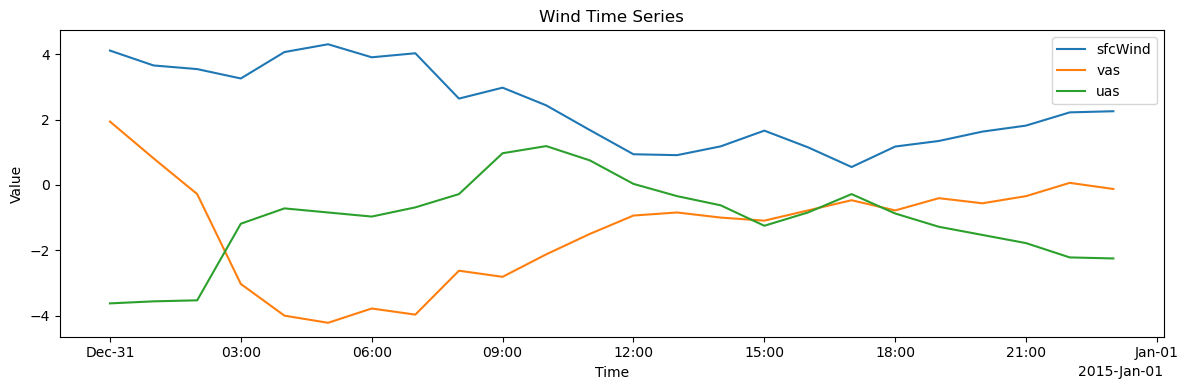

Number of NaNs in rsds: 0
Number of NaNs in rsdsdir: 0


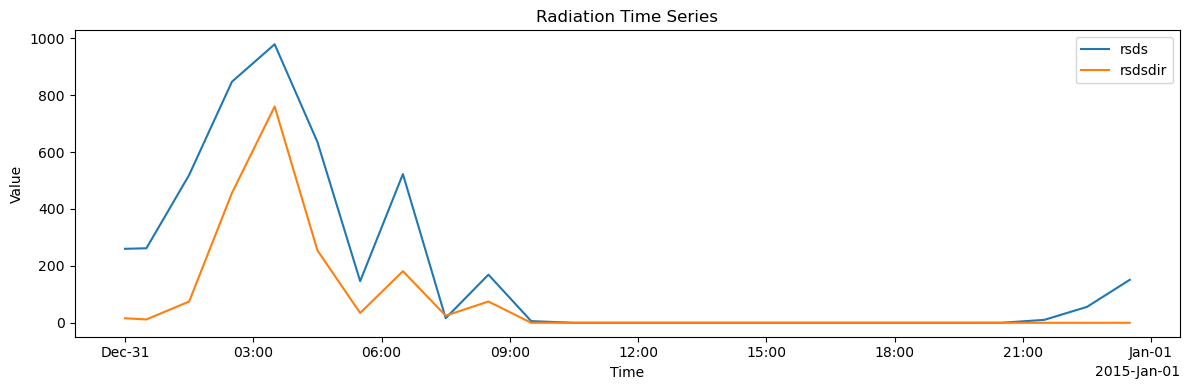

Number of NaNs in psl: 1


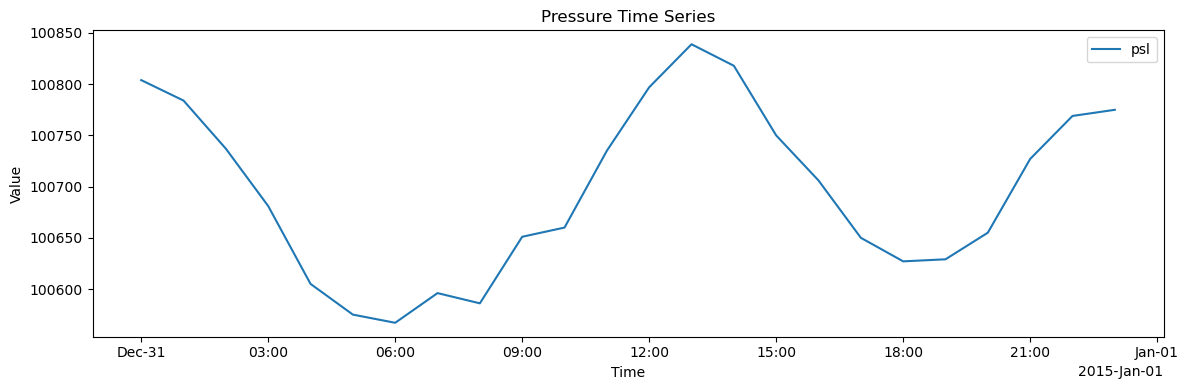

Number of NaNs in clt: 0


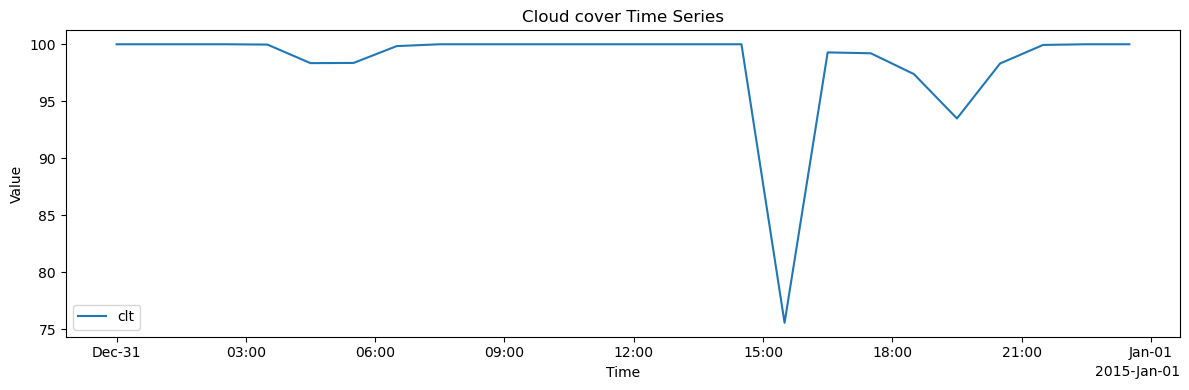

In [8]:
ds = ds.sel(time="2014-12-31")

plot_groups = {
    'Temperature': ['tas'],
    'Humidity': ['huss','hurs'],
    'Wind': ['sfcWind','vas','uas'],
    'Radiation': ['rsds', 'rsdsdir'],
    'Pressure': ['psl'],
    'Cloud cover': ['clt']
}

# Create individual plots
for title, vars in plot_groups.items():
    plt.figure(figsize=(12, 4))
    for var in vars:
        if var in ds:
            nans = ds[var].isnull().sum(dim="time").values
            print(f"Number of NaNs in {var}: {nans}")
            ds[var].plot(label=var)
    plt.title(f'{title} Time Series')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.tight_layout()
    plt.show()